In [14]:
import numpy as np
import matplotlib.pyplot as plt 

In [15]:
N_p = 1000
L = 100
N_grid= 20

In [65]:
# Fix the seed
rng = np.random.default_rng(seed = 42)
pcl_x = rng.uniform(0, L, N_p)
pcl_y = rng.uniform(0, L, N_p)
pcl_z = rng.uniform(0, L, N_p)
r_p = np.array([pcl_x, pcl_y, pcl_z]).T
#### velocity ####
sigma_v = 300 # Km/s
v_x = rng.normal(0, sigma_v, N_p)
v_y = rng.normal(0, sigma_v, N_p)
v_z = rng.normal(0, sigma_v, N_p)
v_p = np.array([v_x, v_y, v_z])
vel = np.linalg.norm(v_p, axis=0)

# Homogenous position

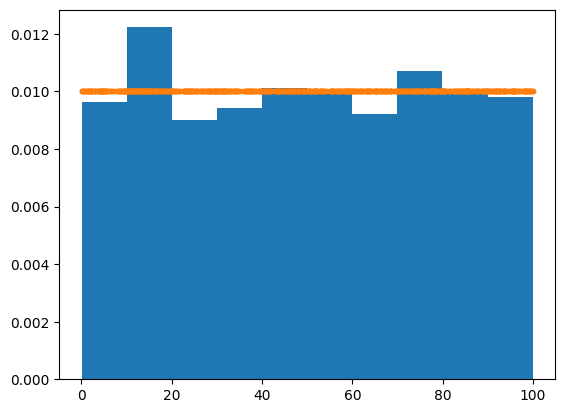

In [66]:
plt.hist(pcl_x, density= True)
plt.plot(pcl_x, pcl_x/(L*pcl_x),".")

# probablity distirbution function for r

In [67]:
np.linalg.norm(x_new, axis=0)

array([61.99240612,  9.13892163, 68.65840543, 42.72819487, 57.42163784,
       62.12710958, 49.62546421, 49.29095145, 55.6849229 , 19.78478868,
       49.71410433, 48.74522962, 38.88326952, 55.69577338, 18.78196673,
       42.31479823, 28.85431353, 72.72962401, 57.6014748 , 18.9260463 ,
       49.35161091, 48.6429531 , 83.65667459, 46.78534271, 32.40125563,
       37.87879416, 54.56035927, 49.08205853, 42.11054272, 22.72309516,
       54.07174041, 51.68159554, 23.34394204, 43.43924304, 40.89123903,
       44.50231713, 59.79374681, 48.70857501, 29.74036486, 48.83347952,
       46.57759219, 47.05484788, 28.60240156, 49.59096865, 75.65622719,
       57.65538923, 32.71266632, 35.26769877, 53.67953415, 46.98419241,
       59.6681205 , 78.36433092, 36.76105027, 52.45555908, 34.63623195,
       33.12849986, 63.13349521, 30.63485648, 51.74320492, 62.4579107 ,
       65.7186612 , 26.03727522, 25.34657376, 50.34820817, 23.70674786,
       64.38631487, 11.65169013, 54.29432152, 71.10584311, 11.83

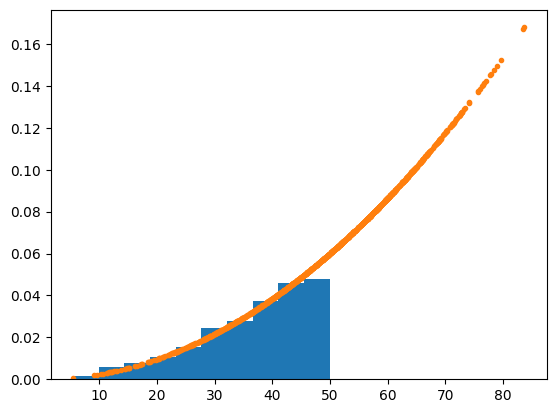

In [69]:
r = np.linalg.norm(r_p, axis=0)
# plt.hist(r, density=True);
# plt.plot(r, 4.0*np.pi*r**2/L**3,".") This is wrong because we have a box but transformation is for a sphere and leads to radii which are not available in the box, instead we shoft the coordinate!
x_new = r_p.T - L/2.;
r_max = L/2.
r_new = np.linalg.norm(x_new, axis=0);
r_filt = r_new[r_new<= r_max]
plt.hist(r_filt,density=True)
plt.plot(r_new, 3*r_new**2/r_max**3,".")

# Gaussian velocity

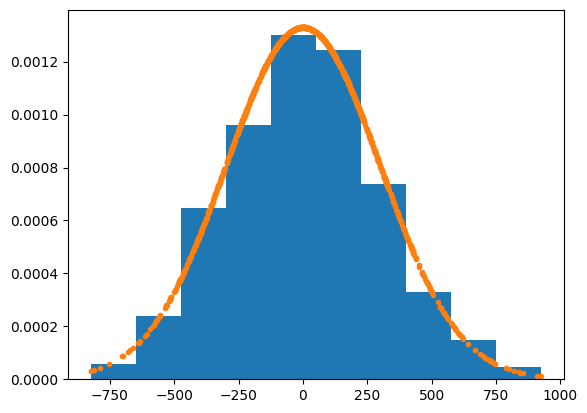

In [70]:
plt.hist(v_x, density=True)
Gauss = 1./np.sqrt(2.*np.pi*sigma_v**2) * np.exp(-v_x**2/(2.* sigma_v**2))
plt.plot(v_x, Gauss, ".")

# Boltzmann distribution

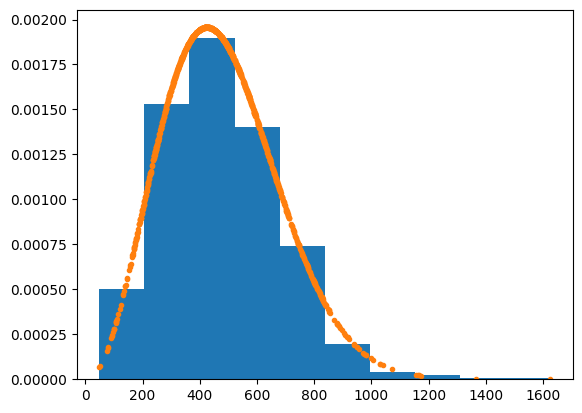

In [71]:
sigma2 = 300**2
plt.hist(vel, density=True)
boltzmann = 4.0 * np.pi/(np.sqrt(2.0 * np.pi * sigma2))**3 * vel**2 * np.exp(- vel**2/2./sigma2)
plt.plot(vel, boltzmann,".")

# CIC & NGP implementation (1D first)

In [72]:
import time
# Here we wanna make the density and number weighted velocities

start_time = time.perf_counter()
Dx = L/N_grid;
# grids = {idx:val for idx, val in enumerate(ngrid_list)}
CIC_field = np.zeros(N_grid, dtype=np.float64)
CIC_vel = np.zeros(N_grid, dtype=np.float64)

x_p_wrapped = pcl_x%L

for num, xp in enumerate(x_p_wrapped):
    i = int(xp/Dx);
    xi = i * Dx;
    dist_x = xp - xi
    vel_p = v_x[num]
    w_left = 1. - dist_x/Dx;
    w_right = 1. - w_left;

    
    CIC_field[i] += w_left
    CIC_vel[i] += w_left * vel_p
    i_right = (i+1)% N_grid
    CIC_field[i_right] += w_right
    CIC_vel[i_right] += w_right * vel_p

## test
end_time = time.perf_counter()

print("Density Check Passed:", np.isclose(np.sum(CIC_field), N_p))
print("Velocity Check Passed:", np.isclose(np.sum(CIC_vel), np.sum(v_x)))
print("time = ", end_time - start_time)

Density Check Passed: True
Velocity Check Passed: True
time =  0.0026272949762642384


## Optimized version using vectorized

In [73]:

start_time = time.perf_counter()
Dx = L/N_grid
CIC_field = np.zeros(N_grid, dtype=np.float64)
CIC_vel = np.zeros(N_grid, dtype=np.float64)
x_p_wrapped = pcl_x%L
i_left = (x_p_wrapped/Dx).astype(np.int64)
Dist_x = x_p_wrapped - i_left*Dx
w_left = 1. - Dist_x/Dx;
np.add.at(CIC_field,i_left, w_left )
np.add.at(CIC_vel,i_left, w_left*v_x )
i_right = (i_left + 1)%N_grid
np.add.at(CIC_field,i_right, 1. - w_left )
np.add.at(CIC_vel,i_right, (1. - w_left)*v_x )

end_time = time.perf_counter()
print("Density Check Passed:", np.isclose(np.sum(CIC_field), N_p))
print("Velocity Check Passed:", np.isclose(np.sum(CIC_vel), np.sum(v_x)))
print("time = ", end_time - start_time)



Density Check Passed: True
Velocity Check Passed: True
time =  0.0016546710394322872


# Highly optimized

In [74]:
import numba as nb
start_time = time.perf_counter()

@nb.njit(fastmath=True)  # No parallel=True needed
def CIC_deposit_1D(pcl_x, vel, L, N_grid):
    CIC_field = np.zeros(N_grid, dtype=np.float64)
    vel_field = np.zeros(N_grid, dtype=np.float64)
    Dx = L / N_grid
    N_p = len(pcl_x)

    for num in range(N_p):  # Standard range
        pos_x = pcl_x[num] % L
        i = int(pos_x / Dx)
        v_x = vel[num]

        deltax = pos_x - i * Dx
        w_left = 1.0 - deltax / Dx
        w_right = 1.0 - w_left

        CIC_field[i] += w_left
        vel_field[i] += w_left * v_x

        i_right = (i + 1) % N_grid
        CIC_field[i_right] += w_right
        vel_field[i_right] += w_right * v_x

    return CIC_field, vel_field

CIC_field, CIC_vel = CIC_deposit_1D(pcl_x, vel, L, N_grid);
end_time = time.perf_counter()
print("Density Check Passed:", np.isclose(np.sum(CIC_field), N_p))
print("Velocity Check Passed:", np.isclose(np.sum(CIC_vel), np.sum(vel)))
print("time = ", end_time - start_time)



Density Check Passed: True
Velocity Check Passed: True
time =  0.16134391818195581


## NGP 1D

In [75]:
# Here we wanna make the density and number weighted velocities
Dx = L/N_grid;
# ngrid_list= np.arange(0, L+Dx, Dx)
# grids = {idx:val for idx, val in enumerate(ngrid_list)}
NGP_field = np.zeros(N_grid, dtype=np.float64)

for xp in pcl_x:
    x_p = (xp%L) 
    i = int(x_p/Dx);
    dist = x_p - i*Dx
    if dist < 0.5 * Dx:
        NGP_field[i] += 1.
    else:
        i_right= (i+1)%N_grid
        NGP_field[i_right] += 1.

## test
print("Important check = ", np.sum(CIC_field) == N_p, ", Number of particles = ", N_p)

Important check =  True , Number of particles =  1000


# 3D, CIC

In [184]:
CIC_field = np.zeros((N_grid, N_grid, N_grid))
CIC_J = np.zeros((3, N_grid, N_grid, N_grid), dtype=np.float64)  # [0]->vx, [1]->vy, [2]->vz

num = len(pcl_x);
r_pcl = r_p % L;
Dx = L/N_grid;
for pcl in range(num):
    i,j,k = int(r_pcl[pcl, 0]/Dx), int(r_pcl[pcl, 1]/Dx), int(r_pcl[pcl, 2]/Dx)
    dist =  r_pcl[pcl] - np.array([i,j,k]) * Dx
    w_x1 = 1. - dist[0]/Dx;
    w_x2 = 1. - w_x1
    w_y1 = 1. - dist[1]/Dx;
    w_y2 = 1. - w_y1
    w_z1 = 1. - dist[2]/Dx;
    w_z2 = 1. - w_z1

    i_r = (i+1)%N_grid
    j_r = (j+1)%N_grid
    k_r = (k+1)%N_grid

    weights = np.array([
        w_x1 * w_y1 * w_z1,
        w_x2 * w_y1 * w_z1,
        w_x1 * w_y2 * w_z1,
        w_x1 * w_y1 * w_z2,
        w_x2 * w_y2 * w_z1,
        w_x2 * w_y1 * w_z2,
        w_x1 * w_y2 * w_z2,
        w_x2 * w_y2 * w_z2
    ])
    corners = [(i,j,k), (i_r,j,k), (i,j_r,k), (i,j,k_r), (i_r,j_r,k), (i_r,j,k_r), (i,j_r,k_r),(i_r,j_r,k_r)]
    v_vec = np.array([v_x[pcl], v_y[pcl], v_z[pcl]])
    for w, (ci,cj,ck) in zip(weights, corners):
        CIC_field[ci, cj, ck] += w
        CIC_J[0, ci, cj, ck] += w * v_vec[0]
        CIC_J[1, ci, cj, ck] += w * v_vec[1]
        CIC_J[2, ci, cj, ck] += w * v_vec[2]

mask = CIC_field > 0
CIC_V = np.zeros_like(CIC_J)
for dim in range(3):
    CIC_V[dim][mask] = (
        CIC_J[dim][mask]
        /
        CIC_field[mask]
    )

# Smoothing R = 10, FFT

In [122]:
from scipy.fft import rfftn, irfftn, rfftfreq, fftfreq

In [228]:
N_grid

20

In [230]:
fftfreq(N_grid)

array([ 0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45, -0.5 , -0.45, -0.4 , -0.35, -0.3 , -0.25, -0.2 , -0.15,
       -0.1 , -0.05])

In [185]:
CIC_k = rfftn(CIC_field) * Dx**3
### bavk to real space
CIC_back_fft = irfftn(CIC_k, s = CIC_field.shape) /Dx**3
Kx = 2. * np.pi * fftfreq(N_grid, d = Dx)
Ky = 2. * np.pi * fftfreq(N_grid, d = Dx)
Kz = 2. * np.pi * rfftfreq(N_grid, d = Dx)
KX, KY, KZ = np.meshgrid(Kx,Ky,Kz, indexing="ij")
K_mag = np.sqrt(KX**2 + KY**2 + KZ**2);

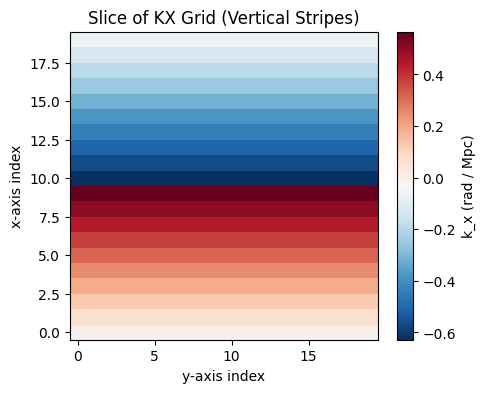

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting a 2D slice [:, :, 0] of KX
plt.figure(figsize=(5, 4))
plt.imshow(KX[:, :, 0], cmap="RdBu_r", origin="lower")
plt.colorbar(label="k_x (rad / Mpc)")
plt.title("Slice of KX Grid (Vertical Stripes)")
plt.xlabel("y-axis index")
plt.ylabel("x-axis index")
plt.show()

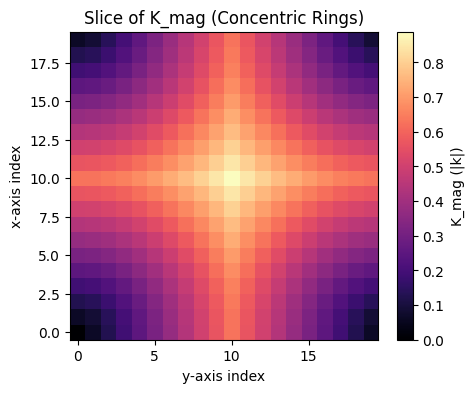

In [187]:
plt.figure(figsize=(5, 4))
plt.imshow(K_mag[:, :, 0], cmap="magma", origin="lower")
plt.colorbar(label="K_mag (|k|)")
plt.title("Slice of K_mag (Concentric Rings)")
plt.xlabel("y-axis index")
plt.ylabel("x-axis index")
plt.show()

In [188]:
R_smooth = 10;

CIC_R_k = CIC_k * np.exp(-K_mag**2 * R_smooth**2/2.)
CIC_back_smooth  = irfftn(CIC_R_k, s =CIC_field.shape )/Dx**3

In [189]:

# A. Mass / Mean Conservation Check
mean_orig = np.mean(CIC_field)
mean_smooth = np.mean(CIC_back_smooth)

# B. Variance Reduction Check (Smoothing lowers variance by wiping out small fluctuations)
var_orig = np.var(CIC_field)
var_smooth = np.var(CIC_back_smooth)

# C. Range Check
print(f"--- DENSITY STATISTICS ---")
print(f"Mean Original:   {mean_orig:.6e}")
print(f"Mean Smoothed:   {mean_smooth:.6e}  --> Difference: {abs(mean_orig - mean_smooth):.2e}")
print(f"Var Original:    {var_orig:.6e}")
print(f"Var Smoothed:    {var_smooth:.6e}  --> Ratio (Smooth/Orig): {var_smooth/var_orig:.2%}")
print(f"Min/Max Orig:    [{np.min(CIC_field):.2f}, {np.max(CIC_field):.2f}]")
print(f"Min/Max Smooth:  [{np.min(CIC_back_smooth):.2f}, {np.max(CIC_back_smooth):.2f}]")

--- DENSITY STATISTICS ---
Mean Original:   1.250000e-01
Mean Smoothed:   1.250000e-01  --> Difference: 0.00e+00
Var Original:    3.871145e-02
Var Smoothed:    2.614423e-04  --> Ratio (Smooth/Orig): 0.68%
Min/Max Orig:    [0.00, 1.77]
Min/Max Smooth:  [0.08, 0.17]


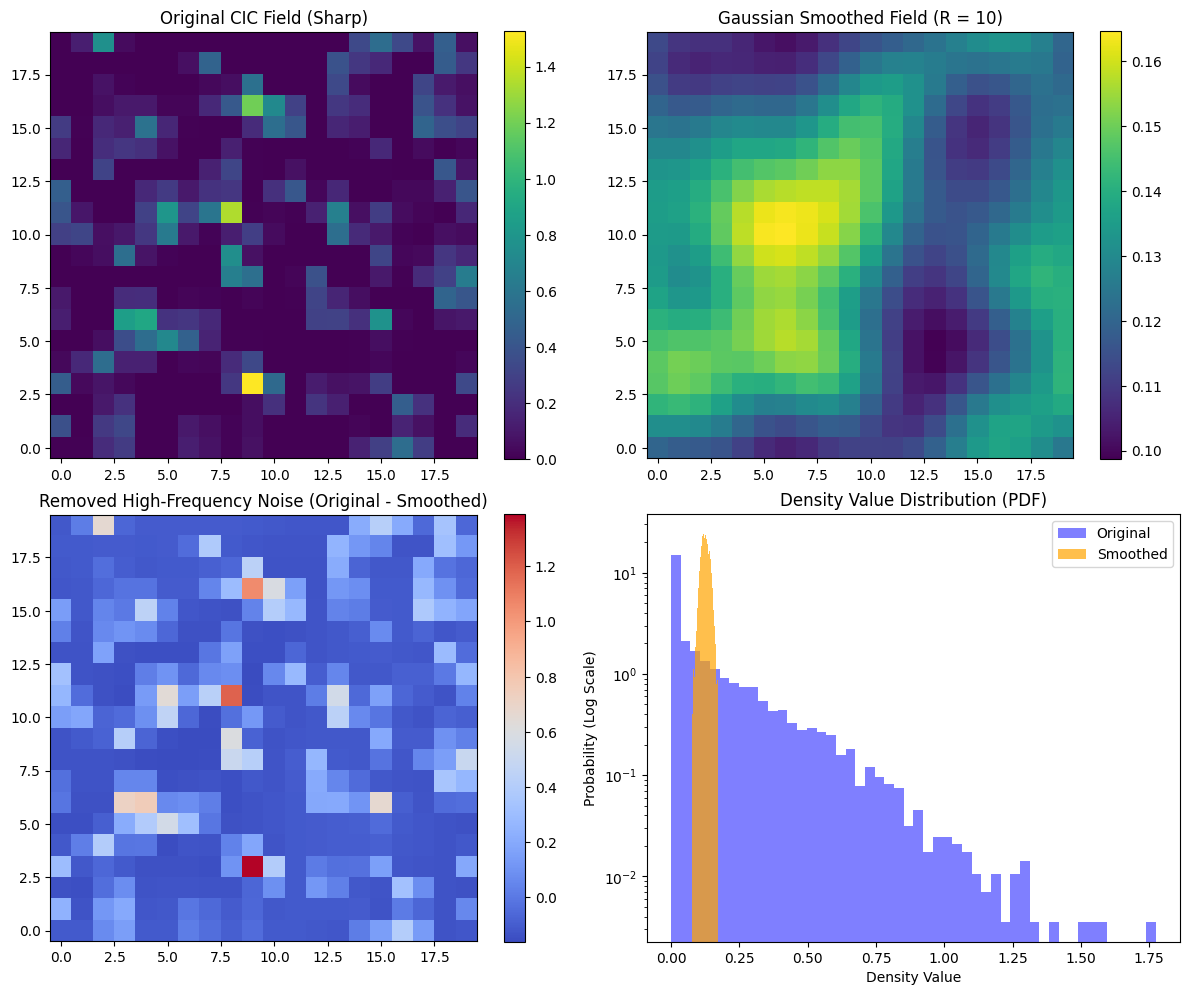

In [190]:
import matplotlib.pyplot as plt

z_slice = N_grid // 2  # Middle slice along z-axis

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Field
im0 = axes[0, 0].imshow(CIC_field[:, :, z_slice], cmap="viridis", origin="lower")
axes[0, 0].set_title("Original CIC Field (Sharp)")
plt.colorbar(im0, ax=axes[0, 0])

# 2. Smoothed Field
im1 = axes[0, 1].imshow(CIC_back_smooth[:, :, z_slice], cmap="viridis", origin="lower")
axes[0, 1].set_title(f"Gaussian Smoothed Field (R = {R_smooth})")
plt.colorbar(im1, ax=axes[0, 1])

# 3. Residual (What was removed?)
residual = CIC_field[:, :, z_slice] - CIC_back_smooth[:, :, z_slice]
im2 = axes[1, 0].imshow(residual, cmap="coolwarm", origin="lower")
axes[1, 0].set_title("Removed High-Frequency Noise (Original - Smoothed)")
plt.colorbar(im2, ax=axes[1, 0])

# 4. Pixel Probability Density Function (1D Density Histogram)
axes[1, 1].hist(CIC_field.flatten(), bins=50, alpha=0.5, label="Original", density=True, color="blue")
axes[1, 1].hist(CIC_back_smooth.flatten(), bins=50, alpha=0.7, label="Smoothed", density=True, color="orange")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Density Value Distribution (PDF)")
axes[1, 1].set_xlabel("Density Value")
axes[1, 1].set_ylabel("Probability (Log Scale)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [194]:
W_R = np.exp(
    -0.5
    *
    K_mag**2
    *
    R_smooth**2
)

n_R = irfftn(
    rfftn(CIC_field) * W_R,
    s=CIC_field.shape
)

Px_R = irfftn(
    rfftn(CIC_J[0]) * W_R,
    s=CIC_field.shape
)

Py_R = irfftn(
    rfftn(CIC_J[1]) * W_R,
    s=CIC_field.shape
)

Pz_R = irfftn(
    rfftn(CIC_J[2]) * W_R,
    s=CIC_field.shape
)

In [195]:
print(
    np.sum(n_R)
    -
    np.sum(CIC_field)
)

0.0


In [197]:
print(
    np.sum(Px_R)
    -
    np.sum(CIC_J[0])
)

1.3642420526593924e-12


In [198]:
Vx_direct_smooth = irfftn(
    rfftn(CIC_V[0]) * W_R,
    s=CIC_field.shape
)

In [199]:
Vx_R = Px_R / n_R

In [203]:
np.isclose(Vx_direct_smooth, Vx_R);

# Computing power spectra

In [219]:
V  = L**3
nbar = np.mean(CIC_field)

delta = (
    CIC_field / nbar
    - 1.0
)
power = np.abs(CIC_k)**2/V

In [220]:
delta_k = rfftn(delta) * Dx**3

V = L**3

power = (
    np.abs(delta_k)**2
    /
    V
)

In [221]:
k_min = 2.* np.pi/L
k_max = np.pi/Dx

In [222]:
k_flat = K_mag.flatten();
power_flat = power.flatten()

In [223]:
n_bins = 20
k_bins = np.linspace(k_min, k_max, n_bins + 1)

In [224]:
p_sum, _ = np.histogram(k_flat, bins=k_bins, weights=power_flat)
k_sum, _ = np.histogram(k_flat, bins=k_bins, weights=k_flat)
counts, _ = np.histogram(k_flat, bins=k_bins)

mask = counts > 0

P_bin = p_sum[mask] / counts[mask]
k_bin = k_sum[mask] / counts[mask]

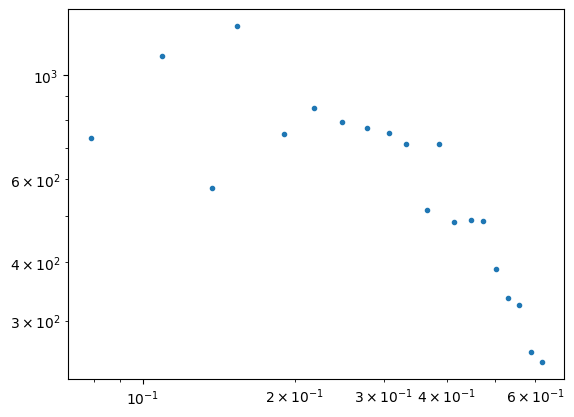

In [225]:
plt.loglog(k_bin, P_bin,".")

Text(0, 0.5, '$P_{\\delta\\delta}(k)$')

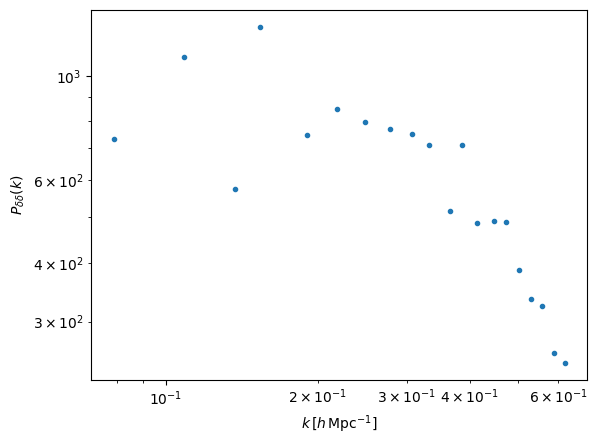

In [226]:
# ------------------------------------------------------------
# Density contrast
# ------------------------------------------------------------

nbar = np.mean(CIC_field)

delta = (
    CIC_field / nbar
    - 1.0
)

# ------------------------------------------------------------
# Fourier transform
# ------------------------------------------------------------

delta_k = (
    rfftn(delta)
    *
    Dx**3
)

# ------------------------------------------------------------
# Power per Fourier mode
# ------------------------------------------------------------

V = L**3

power = (
    np.abs(delta_k)**2
    /
    V
)

# ------------------------------------------------------------
# k range
# ------------------------------------------------------------

k_min = 2.0 * np.pi / L
k_max = np.pi / Dx

# ------------------------------------------------------------
# Flatten modes
# ------------------------------------------------------------

k_flat = K_mag.flatten()
power_flat = power.flatten()

# Remove k=0 and restrict to k <= Nyquist
valid = (
    (k_flat >= k_min)
    &
    (k_flat <= k_max)
)

k_flat = k_flat[valid]
power_flat = power_flat[valid]

# ------------------------------------------------------------
# Bin in |k|
# ------------------------------------------------------------

n_bins = 20

k_bins = np.linspace(
    k_min,
    k_max,
    n_bins + 1
)

p_sum, _ = np.histogram(
    k_flat,
    bins=k_bins,
    weights=power_flat
)

k_sum, _ = np.histogram(
    k_flat,
    bins=k_bins,
    weights=k_flat
)

counts, _ = np.histogram(
    k_flat,
    bins=k_bins
)

nonempty = counts > 0

P_bin = (
    p_sum[nonempty]
    /
    counts[nonempty]
)

k_bin = (
    k_sum[nonempty]
    /
    counts[nonempty]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.loglog(
    k_bin,
    P_bin,
    "."
)

plt.xlabel(
    r"$k\,[h\,{\rm Mpc}^{-1}]$"
)

plt.ylabel(
    r"$P_{\delta\delta}(k)$"
)